# μs-ALEX smFRET burst analysis

*This notebook is part of a tutorial series showing how to migrate from FRETBurts to smfBursts, it follows the structure of the [tutorial series](https://github.com/OpenSMFS/FRETBursts_notebooks) for the [FRETBursts](http://opensmfs.github.io/FRETBursts/) burst analysis software.*

> In this notebook, we present a typical [smfBursts](http://opensmfs.github.io/smfBursts/) 
> workflow for **μs-ALEX smFRET burst analysis**. 
> Briefly, we show how to perform background estimation, burst search, burst selection, 
> compute FRET histograms and ALEX histograms, do sub-population selection and finally, FRET efficiency fit.


Before running the notebook, you can click on menu *Cell* -> *All Output* -> *Clear* 
to clear all previous output. This will avoid mixing output from current execution and 
the previously saved one.

## Loading the software

We start by loading **`smfBursts`**:

In [1]:
import numpy as np
from scipy.optimize import minimize
from scipy.stats import gaussian_kde
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

# from fretbursts import *

import smfbursts as smf
from smfbursts.datamodel import multifit as smfit

<div class="alert alert-info">
Thanks in advance for remembering to <b>cite</b> FRETBursts in publications or presentations!
</div>

Note that FRETBursts **version string** tells you the exact FRETBursts version (and revision) in use.
Storing the version in the notebook helps with reproducibility and 
tracking software regressions.

Next, we set the default plot style with [seaborn](https://seaborn.pydata.org/))

> **Note**
>
> The command `init_notebook` has no equivalent in the new FRETBursts,
> instead you should directly call seaborn commands etc.

In [2]:
# sns = init_notebook()
sns.set_style('darkgrid')

Note that the previous command has no output. Finally, we print the version of some dependencies:

In [3]:
# import lmfit; lmfit.__version__
import lmfit; lmfit.__version__ # note, smfBursts no longer directly depends on lmfit, but does provide some functions for use with lmfit

'1.3.4'

In [4]:
# import phconvert; phconvert.__version__
import phconvert; phconvert.__version__

'0.10.1.post7+g0f279c8b6.d20260515'

## Downloading the data file - skip is file already on you system

The full list of smFRET measurements used in the [FRETBursts tutorials](https://github.com/OpenSMFS/FRETBursts_notebooks) 
can be found on [Zenodo](http://dx.doi.org/10.6084/m9.figshare.1456362).

This is the file we will download:

<div class="alert alert-success">
You can change the <code>url</code>/ <code>doi</code> variable above to download your own data file.
This is useful if you are executing FRETBursts online and you want to use
your own data file. See 
<a href="https://github.com/OpenSMFS/FRETBursts_notebooks/blob/master/notebooks/1.%20First%20Steps%20-%20Start%20here%20if%20new%20to%20Jupyter%20Notebooks.ipynb">First Steps</a>.
</div>

Here, we download the data file and put it in a folder named `data`, 
inside the notebook folder:

In [5]:
# url = 'http://files.figshare.com/2182601/0023uLRpitc_NTP_20dT_0.5GndCl.hdf5'
## doi = 'doi:10.5281/zenodo.20038738'

## download_file(url, save_dir='./data')
## import pooch
# odie = pooch.create(base_url=doi, path='data')
## odie.load_registry_from_doi()
## odie.fetch('0023uLRpitc_NTP_20dT_0.5GndCl.hdf5')

filename = 'data/0023uLRpitc_NTP_20dT_0.5GndCl.hdf5'

> **NOTE**: If you modified the `url` variable providing an invalid URL
> the previous command will fail. In this case, edit the cell containing 
> the `url` and re-try the download.

## Set the data file

If file on disk, set filename, otherwise we just display

In [6]:
# set the file if on disk
# filename = "./data/0023uLRpitc_NTP_20dT_0.5GndCl.hdf5"

filename

'data/0023uLRpitc_NTP_20dT_0.5GndCl.hdf5'

Now `filename` contains the path of the file you just selected. 
Run again the previous cell to select a new file. In a following cell
we will check if the file actually exists.

<div class="alert alert-success">
When running the notebook online and using your own data file,
make sure to modify the previous cell. 
<br>
See
<a href="https://github.com/OpenSMFS/FRETBursts_notebooks/1.%20First%20Steps%20-%20Start%20here%20if%20new%20to%20Jupyter%20Notebooks.ipynb">First Steps</a>.
</div>

### Check that the data file exists

Let's check that the file exists:

In [7]:
import os
if os.path.isfile(filename):
    print("Perfect, file found!")
else:
    print("Sorry, file:\n%s not found" % filename)

Perfect, file found!


## Load the selected file

First we load the data as `raw`

> *Old text*
> 
> We can finally load the data and store it in a variable called `d`:

In [8]:
# d = loader.photon_hdf5(filename)
raw = smf.photonHDF5.load(filename)

If you don't get any message, the file is loaded successfully.

In the original notebook, correction factors are set.
In smfBursts, this is only done later.
Further, these values may be known a-priori, or determined as in [Hellenkamp et. al.](https://doi.org/10.1038/s41592-018-0085-0)
See the [BurstsTutorial](BurstsTutorial.ipynb#Correction-Factors) for an example of this method implemented in smfBursts

For this example, we will simply store the values in their own variables

> **Original text**
>
> We can also set the 3 correction coefficients: 
> 
> * leakage or bleed-through: `leakage`
> * direct excitation: `dir_ex` (ALEX-only)
> * gamma-factor `gamma`

In [9]:
# d.leakage = 0.11
# d.dir_ex = 0.04
# d.gamma = 1.

lk, dir_ex, gamma = 0.11, 0.04, 1.0

## μs-ALEX parameters

We can see the photon times and detectors arrays in `raw.times` an

> **Original Text**
>
>At this point, timestamps and detectors numbers are contained in the `ph_times_t` and `det_t` attributes of `d`. Let's print them:

In [10]:
# d.ph_times_t, d.det_t
raw.times, raw.dets

(array([array([     146847,      188045,      294124, ..., 47999863658,
               47999877783, 47999955353], shape=(2683962,))            ],
       dtype=object),
 array([array([0, 1, 1, ..., 1, 1, 0], shape=(2683962,), dtype=uint32)],
       dtype=object))

We need to define some ALEX parameters: 

In [11]:
# d.add(det_donor_accept = (0, 1), 
#       alex_period = 4000,
#       offset = 700,
#       D_ON = (2180, 3900), 
#       A_ON = (200, 1800))

raw.photon_data[0].meas_specs['alex_period'] = 4000
raw.photon_data[0].meas_specs['alex_offset'] = 700
raw.photon_data[0].meas_specs['alex_excitation_period1'] = np.array([2180, 3900])
raw.photon_data[0].meas_specs['alex_excitation_period2'] = np.array([200, 1800])
raw.photon_data[0].meas_specs['detectors_specs']['spectral_ch1'] = np.array([0], dtype=np.uint8)
raw.photon_data[0].meas_specs['detectors_specs']['spectral_ch2'] = np.array([1], dtype=np.uint8)

Here the parameters are:

- `alex_period`: length of excitation period (in timestamps units)
- `alex_offset` (formerly `offset`): the offset between the start of alternation and start of timestamping 
- `spectral_ch1/2` (formerly `det_donor_accept`): donor and acceptor channels, note that additional spectral channels ie `spectral_ch3,4...` are now allowed.
- `alex_excitation_period1/2'` (fomerly `D_ON` and `A_ON`): donor and acceptor excitation windows. Note that additional excitation ie `alex_excitation_periods3,4,...` are not allowed
  (see also [Definition of alternation periods](http://photon-hdf5.readthedocs.org/en/latest/phdata.html#definition-of-alternation-periods)).

To check that the above parameters are correct, we need to plot the histogram of timestamps (modulo the alternation period) and superimpose the two excitation period definitions to it:

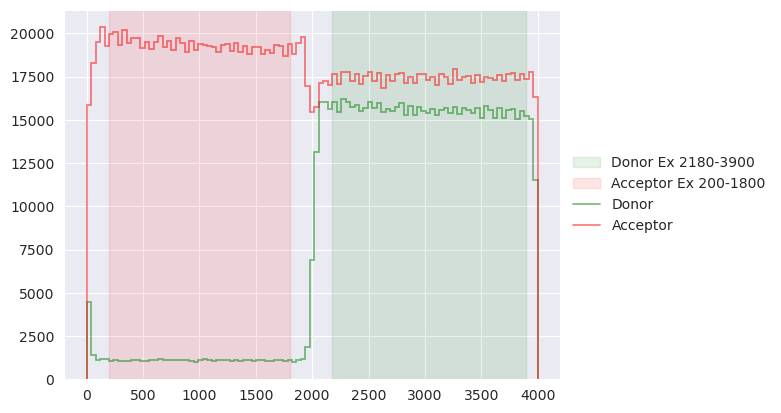

In [12]:
# bpl.plot_alternation_hist(d)
smf.plot.alternation_hist(raw)

If the above histogram does not look correct, modify the various values in the cell before last 
until the histogrma looks correct.

If the previous alternation histogram looks correct, 
the corresponding definitions of the excitation periods can be applied to the data using the following command:

In [13]:
# loader.alex_apply_period(d)
data = smf.photonHDF5.regularize_dets(raw)

### Measurement infos

The new `data` object stores the times (excluding those outside of the alex_periods), and 
the detectors are now "regularized" ie they now follow a specific pattern based
on the number of excitaitons, emission, polarizations and split channels in the experiment.

> **Old text**
> 
> The entire measurement data is now stored in the variable `d`. Printing it
> will give a compact representation containing the file-name and additional parameters:

To check the **measurement duration** (in seconds) run:

In [14]:
# d.time_max
data.times[-1]

np.int64(47999955353)

## Plotting basics

> In this section basic concepts of plotting with FRETBursts using the
> timetrace plot as an example.
>
> To plot a timetrace of the measurement we use:

In smfBursts, the `plot` module is a series of wrappers around matplotlib functions.

The `plot.timetrace` function plots a timed binned trajectory of photon counts per stream.

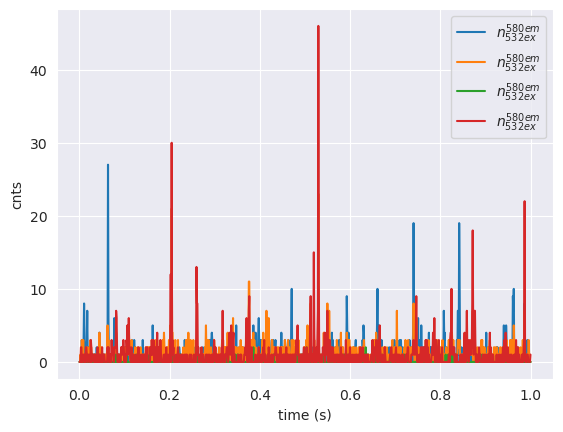

In [15]:
# dplot(d, timetrace);
smf.plot.timetrace(data);

> **Original text**
>
> Here, `dplot` is a generic wrapper (the same for all plots)
> that takes care of setting up the figure, title and axis 
> (in the multispot case `dplot` creates multi-panel plot).
> The second argument, `timetrace`, is the actual plot function. 
> All the eventual additional arguments passed to `dplot` are, 
> in turn, passed to the plot function (e.g. `timetrace`).
>
> If we look at the documentation for [`timetrace`](http://fretbursts.readthedocs.org/en/latest/plots.html#fretbursts.burst_plot.timetrace)
> function we notice that it accepts a long list of arguments.

**Teaching python:**
In python, when an argument is not specified, it will take the default
value specified in the function definition (see previus link).

As an example, to change the bin size (i.e. duration) of the timetrace histogram,
we can look up in the [`timetrace` documentation](http://fretbursts.readthedocs.org/en/latest/plots.html#fretbursts.burst_plot.timetrace)
and find that the argument we need to modify is `binwidth`
(we can also see that the default value is `0.001` seconds).
We can then re-plot the timetrace using a bin of 0.5 ms.
Furhter, we can choose which streams to plot with the streams arguments.
Defaults suplied here by the `fretfactory.ALEXdefaults['streams']` factory instance,
and the direction of the plot set with `direction`.
:

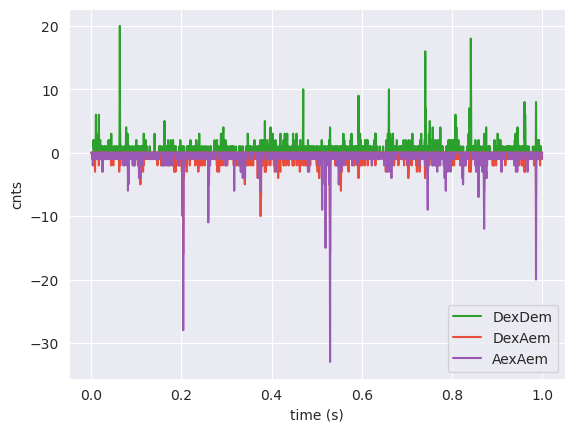

In [16]:
# dplot(d, timetrace, binwidth=0.5e-3);
smf.plot.timetrace(data, streams=smf.fretfactory.ALEXdefaults['streams'][1:],
                   binwidth=0.5e-3, 
                   stream_kwargs=smf.fretfactory.ALEXdefaults['stream_colors', ('label', 'stream_labels')][1:],
                   direction=[1, -1, -1]);

> **Original text**
> 
> The timetrace is **computed** between `tmin` and `tmax` (by default 0 and 200s),
> but as you can see is displayed only between 0 an 1 second, just because these
> are the default x-axis limits. The axis limits can be changes by using the
> standard matplotlib command `plt.xlim()`.
> On the other hand, to change the range where the timetrace is **computed**,
> we pass the additional arguments `tmin` and `tmax` as follows:

We can also control what portion is plotted using the `tmin` and `tmax` keyword arguments.

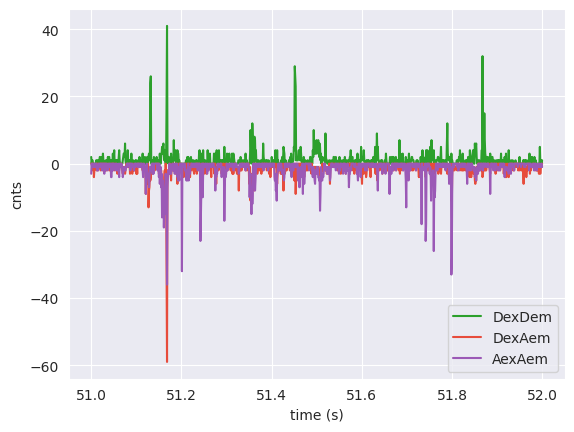

In [17]:
# dplot(d, timetrace, binwidth=0.5e-3, tmin=50, tmax=150)
# plt.xlim(51, 52);
smf.plot.timetrace(data, streams=smf.fretfactory.ALEXdefaults['streams'][1:],
                   tmin=51.0, tmax=52.0, 
                   stream_kwargs=smf.fretfactory.ALEXdefaults['stream_colors', ('label', 'stream_labels')][1:],
                   direction=[True, False, False]);

When using FRETBursts in a notebook, all plots are static by default.
This is because we use the so called `inline` backend of matplotlib.
If you want to manipulate figures interactively, you can switch
to the interactive `ipympl` backend with:

```
%matplotlib ipympl
```

to go back to inline use:


```
%matplotlib inline
```

## Background estimation

As a first step of the analysis, we need to estimate the background. 
Here we will compute the background using the recommended approach of using
the auto-threshold.

For more details see **BackgrounEstimationTutorial**


### Automatic threshold

It is a good practice to monitor background rates as a function of time.
Here, we compute background in adjacent 30s windows (called *background periods*)
and plot the estimated rates as a function of time.


> **smfBursts note**
> 
> The `fretfactory.make_bg` is a "factory" function that produces a dictionary of
> `Param` and `Column` objects, which define *how* to calculate various parameters.
> This function is particulaly formulated for 1 excitation FRET or ALEX/PIE measurements.
> All function inside `fretfactory` are "helper" functions, ie they group a number of
> related calls that are often done together.
> See the [BurstsTutorial](BurstsTutorial.ipynb) notebook for example of how to create
> the constituent objects directly, and what each represents

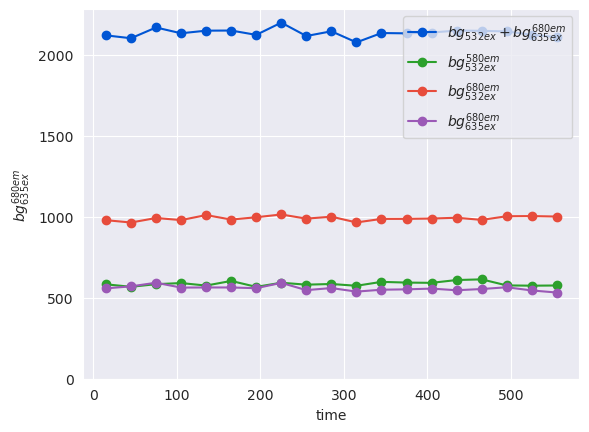

In [18]:
# d.calc_bg(bg.exp_fit, time_s=30, tail_min_us='auto')
bgdct = smf.fretfactory.make_bg(data, func=smf.bg.exp_mlefit, period=30.0, auto_threshold=True, F_bg=1.7)

# dplot(d, timetrace_bg)
# note thate BgDD, BgDA, and BgAA are representative backgroun columns
for col, c in zip(('BgAll', 'BgDD', 'BgDA', 'BgAA'), smf.fretfactory.ALEXdefaults['stream_colors']):
    smf.plot.time_plot(data, bgdct[col], marker='o', **c)
# finally, finishing matplotlib options to control the plot legend and limits
plt.legend()
plt.ylim(0);

## Burst analysis

The first step of burst analysis is the burst search. 

We will use the sliding-window algorithm on all photons. Note 
that "all photons", as mentioned before, means all photons selected in the 
alternation histogram.
An important variation compared to the classical sliding-windows 
is that the threshold-rate for burst start is computed as 
a function of the background and changes when the background
changes during the measurement.

To perform a burst search evaluating the photon rate with 
10 photons (`m=10`), and selecting a minimum rate 6 times larger than 
the background rate (F=6) calculated with all photons (default):

> **Note**
>
> In the original notebook, the now uncommonly used `L` threshold
> was used.
> This is now handled as a part of *gating*, which is handled later.

In [19]:
# d.burst_search(L=10, m=10, F=6)
bsdct = smf.fretfactory.make_burst_search(bg=bgdct['bg'], m=10, F=6.0, streams=smf.PhSel('0ex_1ex1em'), lk=lk, dir_ex=dir_ex, gamma=gamma)
# note: in keeping with Hellencamp, the lk kwarg can also be specified as alpha, and dir_ex as delta, see bellow
# bsdct = smf.fretfactory.make_burst_search(bg=bgdct['bg'], m=10, F=6.0, streams=smf.PhSel('0ex_1ex1em'), alpha=lk, delta=dir_ex, gamma=gamma)

> **Original Text**
>
>The previous command performs the burst search, corrects 
> the bursts sizes for background, spectral leakage and direct excitation,
> and computes $\gamma$-corrected FRET and Stoichiometry. 
>
> See the 
> [`burst_search` documentation](http://fretbursts.readthedocs.org/en/latest/data_class.html#fretbursts.burstlib.Data.burst_search) for more details.
>
> We can plot the resulting FRET histogram using the following command:

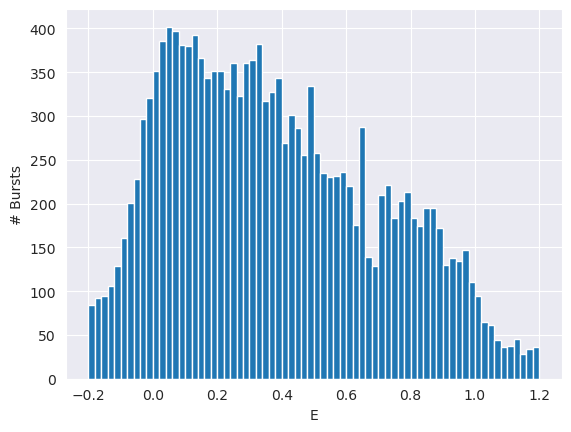

In [20]:
# dplot(d, hist_fret);
smf.plot.hist_bar(data, bsdct['E'], bins=smf.fretfactory.ALEXdefaults['ratio_bins']);

> **Original Text**
>
>All pre-defined plots follow this pattern: 
> call the generic `dplot()` function, passing 2 parameters:
> 
> - the measurement data (`d` in this case) 
> - the plot function (`hist_fret`)
> 
> In some case we can add other optional parameters to tweak the plot.
> 
> All plot functions start with `hist_` for histograms, 
> `scatter_` for scatter-plots  or `timetrace_` for plots as a function 
> of measurement time. You can use autocompletion to find all 
> plot function or you can look in `bursts_plot.py` where 
> all plot functions are defined.

Instead of `hist_fret` we can use `smfhist_fret_kde()` 
to add a [KDE](http://en.wikipedia.org/wiki/Kernel_density_estimation) overlay.
Also, we can plot a **weighted histogram** by passing an additional parameter `weights`:

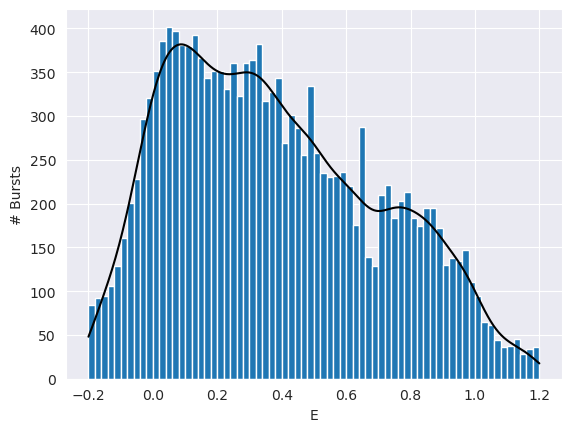

In [21]:
# dplot(d, hist_fret, show_kde=True);
# dplot(d, hist_fret, show_kde=True, weights='size');
smf.plot.hist_kdeoverlay(data, bsdct['E'], bins=smf.fretfactory.ALEXdefaults['ratio_bins'], kdeplot_kwargs={'c':'k'});

> **Original Text**
> You can experiment with different weighting schema (for all 
> supported weights see `get_weigths()` function in `fret_fit.py`).
>
> **New method**
> You can change the method for weigthing and determining
> the dispersion of individual bursts in computing the kde
> through the `kde_kwargs` keyword argument. This is a dictionary
> passed to [scipy.stats.gaussian_kde](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.gaussian_kde.html)

### Burst selection

> **Deprecated**
>
> When we performed the burst search, we specified `L=10` without 
> explaining what this parameter means. *L* is traditionally the minimum size 
> (number of photons) for a burst: smaller bursts will be rejected. 
> By setting L=m (10 in this case) we are deciding to not discard 
> any burst (because the smallest detected burst has at least *m* counts).
>
> **Updated behavior**
>
> All L-like threshholds now handled by setting a gate, as demonstrated below

Selecting the bursts in a second step, by applying a minimum burst size criterion, 
results in a more accurate and unbiased selection.

> **Original Text**
>
> For example, we can select bursts with more than 30 photons (after 
> background, gamma, leakage and direct excitation corrections)
> and store the result in a new
> `Data()` variable `ds`:

We do this by specifying a `Column` (keys beginning with capital letters)
of a number of photons (these always begin with `Nph` followed by stream specification)
and the level of correction factors to apply
(the end, options are `_raw`, `_bg` and `_c`, indicating 
raw counts, background corrected counts, and fully corrected that is alpha, beta, delta and gamma, counts respectively).

To match the old notebook, the "size" is equivalent to corrected Donor excitation streams, 
so `NphDex_c`, and we make a gate from this:

In [22]:
# ds = d.select_bursts(select_bursts.size, th1=30)
gDact = smf.make_geq_gate(bsdct['NphDex_c'], 30.0)

> **Original Text**
> By defaults the burst size includes donor and acceptor photons during donor excitation. 
> To add acceptor photons during acceptor excitation (`naa`), we add the parameter `add_naa=True`:

To match the old notebook, the column for "size" with the "add_naa" option
is `NphActive_c`:

In [23]:
# ds = d.select_bursts(select_bursts.size, add_naa=True, th1=30)
gAll = smf.make_geq_gate(bsdct['NphActive_c'], 30.0)

Similar to plot functions, all selection functions 
are defined in `select_bursts.py` and you can access them by typing 
`select_bursts.` and using the TAB key for autocompletion. 

> **Original Text See also:** 
> * [Burst selection](http://fretbursts.readthedocs.org/en/latest/burst_selection.html) in the documentation. 
> In particular the function
> [`select_bursts.size`](http://fretbursts.readthedocs.org/en/latest/burst_selection.html#fretbursts.select_bursts.size)
> and [`Data.select_bursts`](http://fretbursts.readthedocs.org/en/latest/data_class.html#fretbursts.burstlib.Data.select_bursts).
>
> **Migrating to `smfBursts`**
>
> Burst selection is now done through Gates
> These use columns described previously, and are much more flexible
> See the [Gates tutorial](GatesTutorial.ipynb) for a detailed tutorial. 

> **Original Text**
>
> To replot the FRET histogram after selection (note that now we are passing `ds` to the plot function):

We can now replot the filtered histogram by supplying the `gAll` gate as
a keyword argument to the `hist_bar` function:

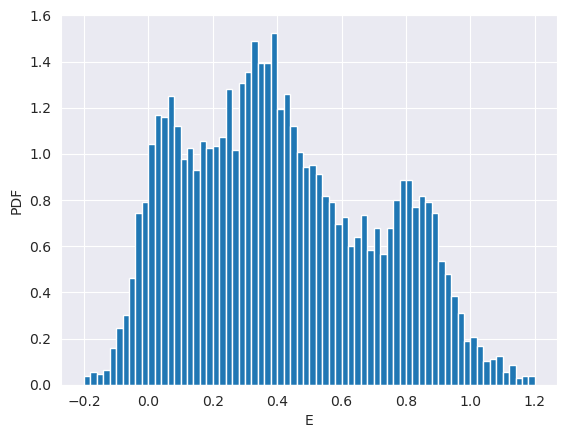

In [24]:
# dplot(ds, hist_fret);

smf.plot.hist_bar(data, bsdct['E'], gate=gAll, bins=smf.fretfactory.ALEXdefaults['ratio_bins'], normalize='PDF');

We will now make a gate that ensures all bursts are within the E range 
(background correction will not result in "straggler" bursts).

In [25]:
gAll_lim = gAll & smf.make_geq_gate(bsdct['E'],-0.2) & smf.make_lt_gate(bsdct['E'], 1.2)

Note how the histogram exhibits much more clearly defined peaks after burst selection. 

### Histogram fitting and plotting style

> **Original Text**
> Under the hood the previous `hist_fret` plot creates a `MultiFitter` 
> object for $E$ values. This object, stored as `ds.E_fitter`, operates
> on multi-channel data and computes the histogram, KDE and can fit 
> the histogram with a model ([lmfit.Model](http://lmfit.github.io/lmfit-py/model.html)).
>
> Now, just for illustration purposes, we fit the previous histogram with 3 Gaussians, using the already created `ds.E_fitter` object:

smfBursts no longer attaches fits and histograms directly to the data object.
Rather, to fit a histogram of a given column and burst selection, we create
a `Hist` object, which wrapps [np.histogramdd](https://numpy.org/doc/stable/reference/generated/numpy.histogramdd.html).

This can then be fit with an array of "multi" distributions.
Instead of creating separate 1, 2, 3 ... gaussian functions,
the `smfit.ngaus_cdfbins`, `smfit.ngaus_pdf` functions use the size of the `params` array
to determine the number of gaussian distributions.
This way we can fit the hist, with `smfit.fit_hist_cdf` 
(a thin wrapper around [scipy.optimize.minimize](https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.minimize.html))
and plot the returned minimizer result with `plot.plot_multi_dist`.

       message: Optimization terminated successfully.
       success: True
        status: 0
           fun: 0.00011876363888930495
             x: [ 3.705e-02  6.614e-02  1.395e-01  3.496e-01  1.862e-01
                  7.440e-01  8.241e-01  1.139e-01]
           nit: 961
          nfev: 1397
 final_simplex: (array([[ 3.705e-02,  6.614e-02, ...,  8.241e-01,
                         1.139e-01],
                       [ 3.706e-02,  6.612e-02, ...,  8.241e-01,
                         1.139e-01],
                       ...,
                       [ 3.706e-02,  6.612e-02, ...,  8.241e-01,
                         1.139e-01],
                       [ 3.707e-02,  6.616e-02, ...,  8.241e-01,
                         1.139e-01]], shape=(9, 8)), array([ 1.188e-04,  1.188e-04,  1.188e-04,  1.188e-04,
                        1.188e-04,  1.188e-04,  1.188e-04,  1.188e-04,
                        1.188e-04]))

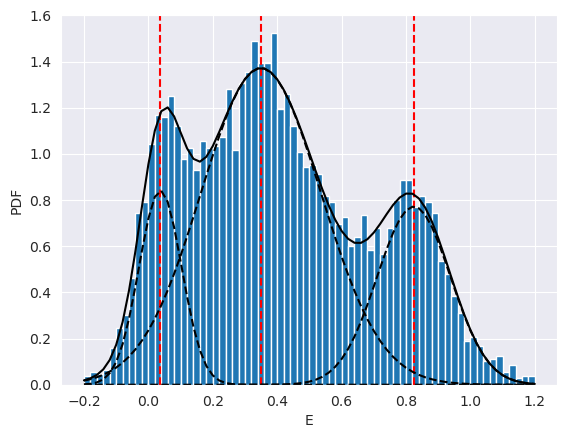

In [26]:
# ds.E_fitter.fit_histogram(mfit.factory_three_gaussians(), verbose=False)

# generate histogram
hst = smfit.Hist.from_columns(data, bsdct['E'], gate=gAll, bins=smf.fretfactory.ALEXdefaults['ratio_bins'])
# set init and bounds, since number of distributions is arbitrary, these can no longer be given defaults
init = smfit.make_init([0.2, 0.5, 0.8], [0.2, 0.2, 0.2], amps=[0.4, 0.3, 0.3])
bounds = smfit.make_bounds([[0.0, 1.0],[0.0, 1.0], [0.0, 1.0]], [[1e-4, 0.4], [1e-4, 0.4], [1e-4, 0.4]])
# perform fit
mn = smfit.fit_hist_cdf(hst, smfit.ngaus_cdf, init, bounds=bounds, method='Nelder-Mead')
res = smfit.unwrap_param(smfit.ngaus_cdfbins, mn.x) # convenience, groups param types
# plot centers of distribution
for center in res['mu']:
    plt.axvline(center, ls='--', c='r')

# plot data
smf.plot.hist_bar(data, bsdct['E'], gate=gAll, bins=hst.bins[0], normalize='PDF')
# plot fit distribution
smf.plot.plot_multi_dist(smfit.ngaus_pdf, mn.x, hst.bins[0], subdist_kwargs={'ls':'--'}, c='k')
mn

**New to smfBursts**

MLE methods *can* be more accurarte than fitting with least squares,
as they do not invovle any binning.

We can also perform an MLE fit of a given collumn as follows:

{'mu': array([0.04205301, 0.35256161, 0.80792823]),
 'sigma': array([0.07582737, 0.16355514, 0.13293823]),
 'amps': array([0.17564415, 0.57100578, 0.25335007])}

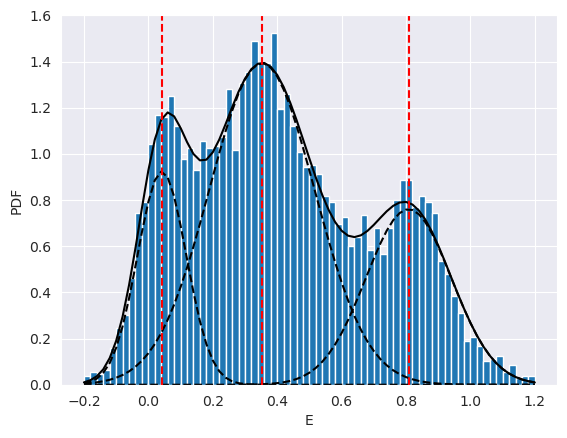

In [27]:
init = smfit.make_init([0.2, 0.5, 0.8], [0.2, 0.2, 0.2], amps=[0.4, 0.3, 0.3])
bounds = smfit.make_bounds([[0.0, 1.0],[0.0, 1.0], [0.0, 1.0]], [[1e-4, 0.4], [1e-4, 0.4], [1e-4, 0.4]])
# fit, note we need to gate between -0.2 and 1.2, because there may be very small/large values that will result in -inf pdf values
mn = smfit.fit_column_mle(data, bsdct['E'], smfit.ngaus_pdf, init, 
                          gate=gAll_lim, bounds=bounds, 
                          method='Nelder-Mead')  # note, Nelder-Mean is better search algroithm for MLE

smf.plot.hist_bar(data, bsdct['E'], gate=gAll, bins=hst.bins[0], normalize='PDF')
smf.plot.plot_multi_dist(smfit.ngaus_pdf, mn.x, hst.bins[0], subdist_kwargs={'ls':'--'}, c='k')
res = smfit.unwrap_param(smfit.ngaus_pdf, mn.x)
for center in res['mu']:
    plt.axvline(center, ls='--', c='r')
res

> **Original Text**
>
> The bin width can be changed with `binwidth` argument. Alternatively,
> an arbitrary array of bin edges can be passed in `bins` (overriding `binwidth`).
>
> We can customize the appearance of this plot (type `hist_fret?` for the complete set of arguments). 
>
> For example to change from a bar plot to a line-plot we use the `hist_style` argument:


We can change the style by selecting different `plot.hist_...` functions,
and supplying matplotlib keyword arguments to them.

Changing binwidts is done through passing different values to `bins`

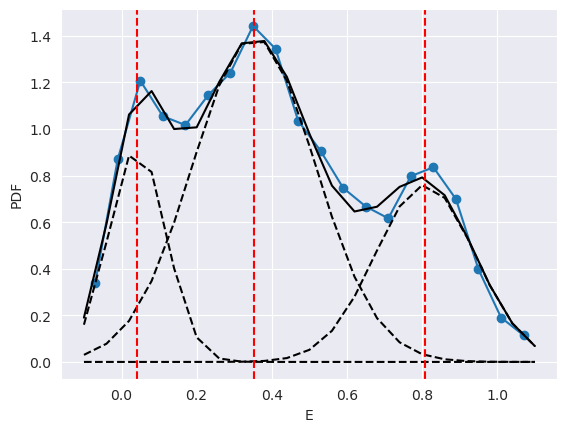

In [28]:
# dplot(ds, hist_fret, show_model=True, hist_style='line')

smf.plot.hist_line(data, bsdct['E'], gate=gAll, bins=np.linspace(-0.1,1.1,21), normalize='PDF', marker='o')

smf.plot.plot_multi_dist(smfit.ngaus_pdf, mn.x, np.linspace(-0.1,1.1,21), subdist_kwargs={'ls':'--'}, c='k')
res = smfit.unwrap_param(smfit.ngaus_pdf, mn.x)
for center in res['mu']:
    plt.axvline(center, ls='--', c='r')

We can customize the line-plot, bar-plot, the model 
plot and the KDE plot by passing dictionaries with matplotlib 
style. The name of the arguments are:

- `hist_plot_style`: style for the histogram line-plot
- `hist_bar_style`: style for the histogram bar-plot
- `model_plot_style`: style for the model plot
- `kde_plot_style`: style for the KDE plot

As an example:

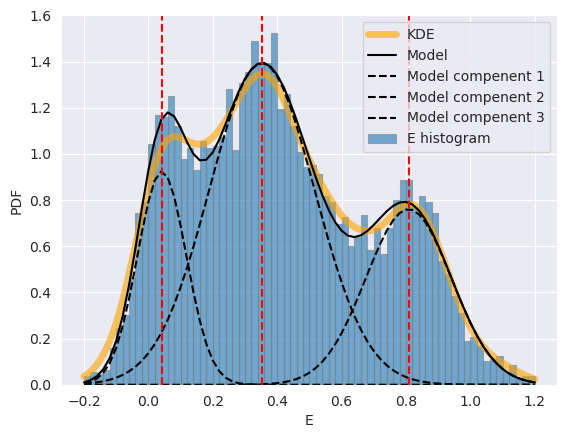

In [29]:
# dplot(ds, hist_fret, show_model=True, hist_style='bar', show_kde=True,
#       kde_plot_style = dict(linewidth=5, color='orange', alpha=0.6),
#       hist_plot_style = dict(linewidth=3, markersize=8, color='b', alpha=0.6))
# plt.legend();

smf.plot.hist_kdeoverlay(data, bsdct['E'], gate=gAll, bins=hst.bins[0], # plot burst histogram
                         kdeplot_kwargs=dict(linewidth=5, color='orange', alpha=0.6, label='KDE'),
                         linewidth=0.8, alpha=0.6, color='#1f77b5', normalize='PDF', edgecolor='grey',
                         label='E histogram')

smf.plot.plot_multi_dist(smfit.ngaus_pdf, mn.x, hst.bins[0], c='k', # plot fit
                         dist_kwargs={'label':'Model'}, 
                         subdist_kwargs=[{'ls':'--', 'label':f'Model compenent {i+1}'} for i in range(3)])
res = smfit.unwrap_param(smfit.ngaus_pdf, mn.x)

for center in res['mu']:
    plt.axvline(center, ls='--', c='r') # loop for vertical center lines
plt.legend()

## Other plots

Similarly, we can plot the burst size using all photons 
(type `hist_size?` to learn about all plot options):

(0.0, 2000.0)

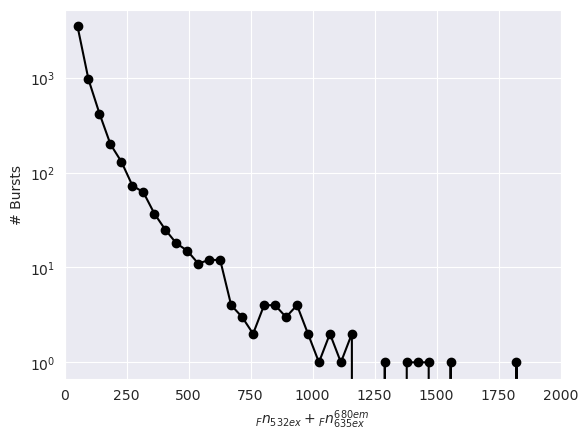

In [30]:
# dplot(ds, hist_size, add_naa=True);
smf.plot.hist_line(data, bsdct['NphActive_c'], gate=gAll, marker='o', c='k')
plt.yscale('log')
plt.xlim(0, 2000)

Or plot the burst size histogram for the different components:

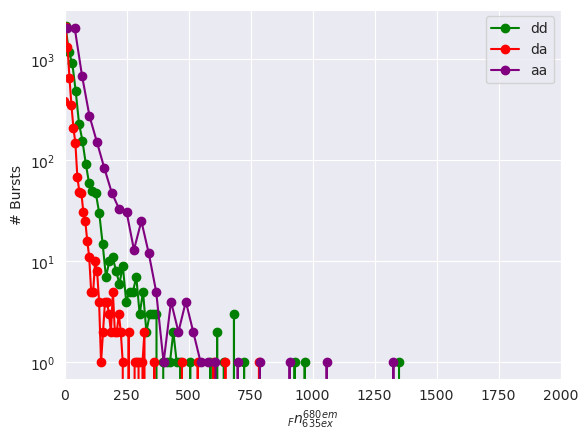

In [31]:
# dplot(ds, hist_size_all);
smf.plot.hist_line(data, bsdct['NphDD_c'], gate=gAll, marker='o', c='green', label='dd')
smf.plot.hist_line(data, bsdct['NphDA_c'], gate=gAll, marker='o', c='red', label='da')
smf.plot.hist_line(data, bsdct['NphAA_c'], gate=gAll, marker='o', c='purple', label='aa')
plt.legend()
plt.xlim(0,2000)
plt.yscale('log')

> **NOTE:** The previous plot may generate a benign warning 
> due to the presence of zeroes when switching to log scale. Just ignore it.

A scatterplot of Size *vs* FRET is created by:

(-1.0, 2.0)

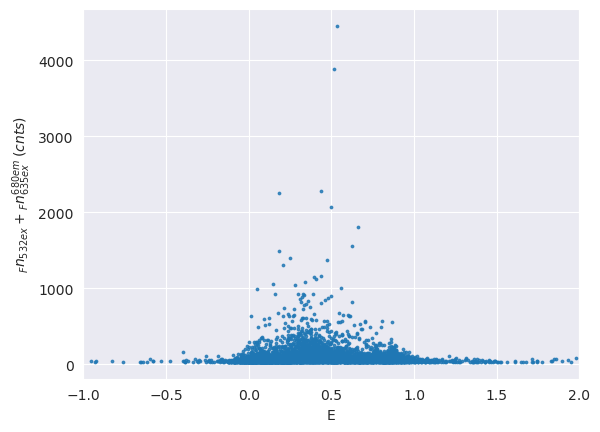

In [32]:
# dplot(ds, scatter_fret_nd_na)
smf.plot.scatter(data, bsdct['E'], bsdct['NphActive_c'], gate=gAll, s=3.0, alpha=0.8)
plt.xlim(-1, 2)

## Study of different populations

### Removing multi-mers

We can further select only bursts smaller than 300 photons 
to get rid of multi-molecule events:

In [33]:
# ds2 = ds.select_bursts(select_bursts.size, th2=300)
gNomulti = gAll & smf.make_lt_gate(bsdct['NphDex_c'], 300)

and superimpose the two histograms before and after selection to see the difference:

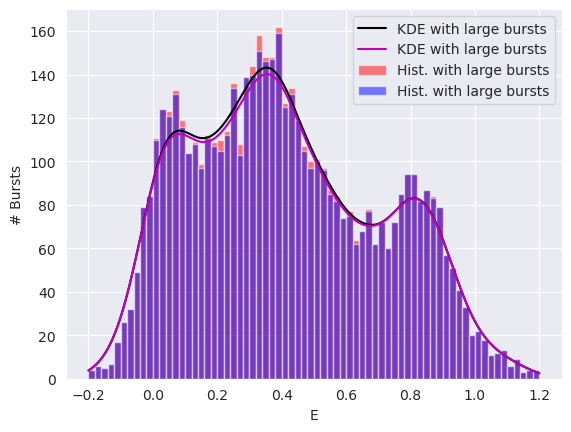

In [34]:
# ax = dplot(ds2, hist_fret, hist_style='bar', show_kde=True, 
#               hist_bar_style = dict(facecolor='r', alpha=0.5, 
#                                     label='Hist. no large bursts'),
#               kde_plot_style = dict(lw=3, color='m', 
#                                     label='KDE no large bursts'))
# dplot(ds, hist_fret, ax=ax, hist_style='bar', show_kde=True,
#       hist_bar_style = dict(label='Hist. with large bursts'),
#       kde_plot_style = dict(lw=3, label='KDE with large bursts'))
# plt.legend();

smf.plot.hist_kdeoverlay(data, bsdct['E'], gate=gAll, label='Hist. with large bursts', 
                         kdeplot_kwargs={'c':'k', 'label':'KDE with large bursts'}, 
                         bins=smf.fretfactory.ALEXdefaults['ratio_bins'], alpha=0.5, facecolor='r')
smf.plot.hist_kdeoverlay(data, bsdct['E'], gate=gNomulti, label='Hist. with large bursts', 
                         kdeplot_kwargs={'c':'m', 'label':'KDE with large bursts'}, 
                         bins=smf.fretfactory.ALEXdefaults['ratio_bins'], alpha=0.5, facecolor='b')
plt.legend()

> **NOTE:** It is not necessarily true that bursts with more that 300 photons 
> represents multiple molecules. 
> To asses the valididty of this assumption it can be useful to 
> plot the peak count rates in each burst. See `hist_burst_phrate` 
> for this kind of plot.

### Fit and plot peak positions

> **Original Text**
>
> We can find the KDE peak position in a range (let say 0.2 ... 0.6):

in smfBursts, we evaluate the KDE directly

In [35]:
# ds.E_fitter.find_kde_max(np.r_[0:1:0.0002], xmin=0.2, xmax=0.6)
kde_max = np.r_[0.2:0.6:0.0002][np.argmax(gaussian_kde(data.get_column(bsdct['E'], gAll_lim))(np.r_[0.2:0.6:0.0002]))]
kde_max

np.float64(0.3528000000000044)

and plot it with `show_kde_peak=True`, we also use `show_fit_value=True` to show a box with the fitted value:

Text(0.6, 0.9, '$max(KDE(^{iii}E))={0.352800}$')

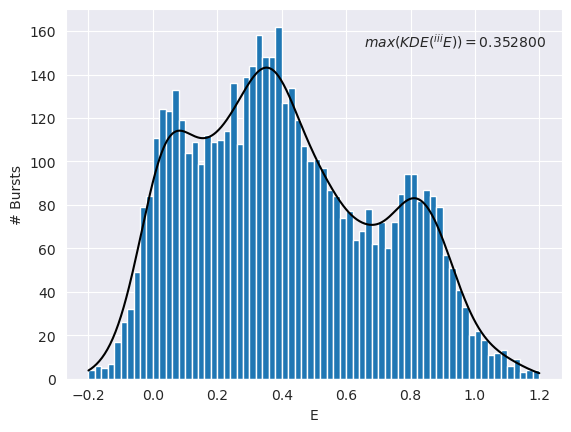

In [36]:
# dplot(ds, hist_fret, hist_style='line', 
#       show_fit_value=True, 
#       show_kde=True, show_kde_peak=True);
smf.plot.hist_kdeoverlay(data, bsdct['E'], bins=smf.fretfactory.ALEXdefaults['ratio_bins'], 
                         kdeplot_kwargs={'c':'k'}, gate=gAll)
plt.annotate(r'$max(KDE(^{iii}E))={%f}$'%kde_max, (0.6, 0.9), xycoords='axes fraction')

> **Original Text**
>
> Instead of using the KDE, we can use the peak position as fitted from a gaussian model.

The `'mu'` key in `res` from the call `res = smfit.unwrap_param(smfit.ngaus_pdf, mn.x)`
enumerates the centers of each population.

In [37]:
# ds.E_fitter.fit_histogram(mfit.factory_three_gaussians(), verbose=False)
res = smfit.unwrap_param(smfit.ngaus_pdf, mn.x)
res['mu']

array([0.04205301, 0.35256161, 0.80792823])

To select which peak to show we use `fit_from='p1_center'`:

Text(0.72, 0.9, '$^{iii}E_{fit 3}={0.807928}$')

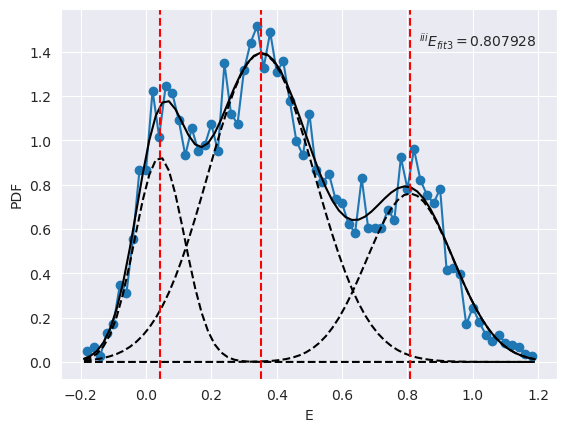

In [38]:
# dplot(ds, hist_fret, hist_style='line', 
#       show_fit_value=True, fit_from='p2_center', 
#       show_model=True);
smf.plot.hist_line(data, bsdct['E'], bins=hst.bincenters[0], gate=gAll, normalize='PDF', marker='o')
smf.plot.plot_multi_dist(smfit.ngaus_pdf, mn.x, hst.bincenters[0], subdist_kwargs={'ls':'--'}, c='k')
for center in res['mu']:
    plt.axvline(center, ls='--', c='r')
plt.annotate(r'$^{iii}E_{fit 3}={%f}$'%res['mu'][2], (0.72, 0.9), xycoords='axes fraction')

> **Original text**
> The string `'p2_center'` is the name of the parameter of the gaussian fit that we want to show in the text box. To see all 
> the parameters of the model we look in:

As disucssed before, we can access the center through the `mu` varaible:

In [39]:
# ds.E_fitter.params  # <-- pandas DataFrame, one row per channel
res['mu']

array([0.04205301, 0.35256161, 0.80792823])

### ALEX plots

> **Original Text**
>
> We can create a simple E-S scatter plot with `scatter_alex`:

Using `plot.scatter()` we can plot alex with the `E` and `S` columns

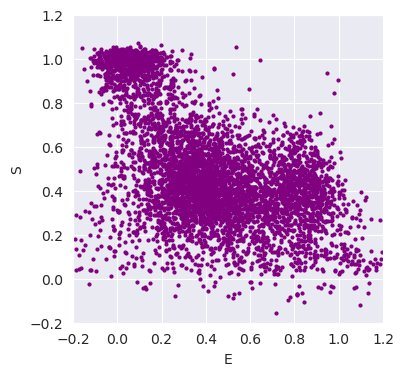

In [40]:
# dplot(ds, scatter_alex, figsize=(4,4), mew=1, ms=4, mec='black', color='purple');
fig = plt.figure(figsize=(4,4))
smf.plot.scatter(data, bsdct['E'],bsdct['S'], gate=gAll, lw=1, s=4, c='purple')
plt.xlim(-0.2, 1.2)
plt.ylim(-0.2, 1.2);

We can also plot the ALEX histogram with a scatterplot overlay using `hist2d_alex`:

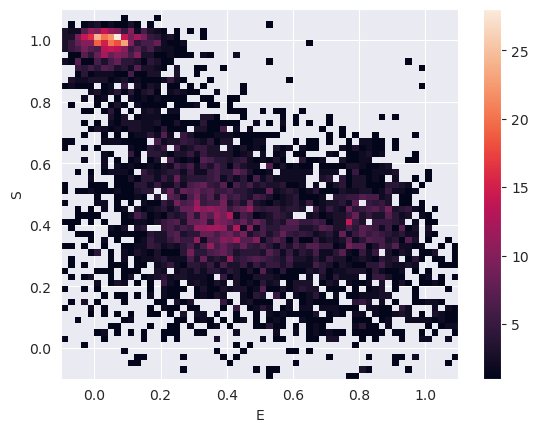

In [41]:
# dplot(ds, hist2d_alex);
# smf.plot.kdeplot(data, bsdct['E'], bsdct['S'], gate=gAll_lim)
_, _, _, cm, *_ = smf.plot.hist2d(data, bsdct['E'], bsdct['S'], gate=gAll, bins=[np.r_[-0.1:1.1:0.02] for _ in range(2)], cmin=1)
plt.colorbar(cm)

Finally we can also plot an ALEX histogram and marginals 
(joint plots) as follow (for more options see: 
**Plotting tutorial**

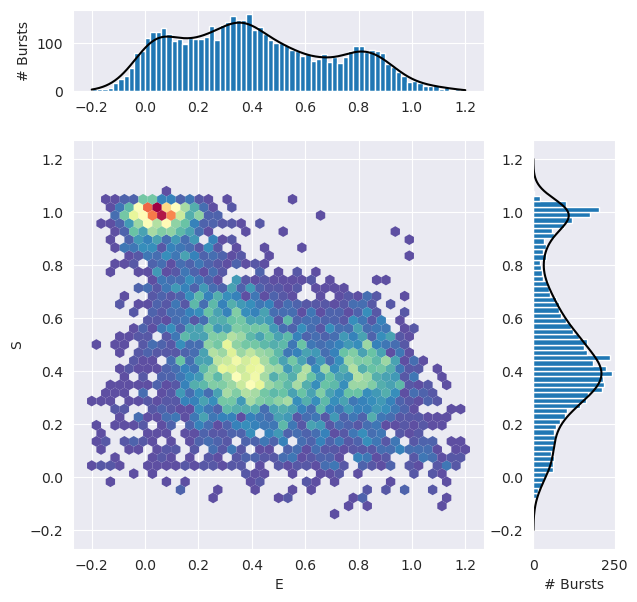

In [42]:
# alex_jointplot(ds);
fig = plt.figure(figsize=(7,7))
cplotkw = smf.fretfactory.ALEXdefaults['hexbin']
cplotkw['cmap'] = 'Spectral_r'
smf.plot.jointplot(data, bsdct['E'], bsdct['S'], fig=fig, gate=gAll, hfunc=smf.plot.hist_kdeoverlay, cfunc=smf.plot.hexbin,
                   hplot_kwargs={'kdeplot_kwargs':{'c':'k'}, 'bins':smf.fretfactory.ALEXdefaults['ratio_bins']},
                   cplot_kwargs=cplotkw);

To get rid of the large donor-only population, we can simply 
select bursts with at least 10 photons in the acceptor channel 
(during acceptor excitation). At the same time,
with a burst size selection using Dex photons we get rid
of the A-only population:

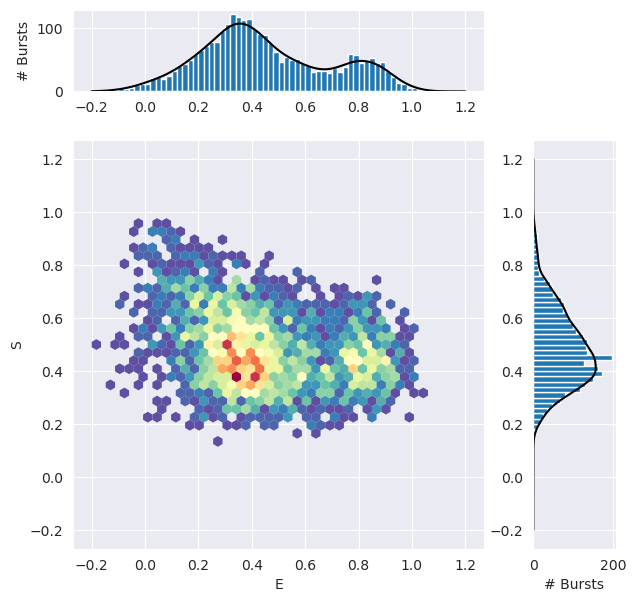

In [43]:
# ds = d.select_bursts(select_bursts.size, th1=20)
# ds2 = ds.select_bursts(select_bursts.naa, th1=10)
gAll2 = smf.make_geq_gate(bsdct['NphDex_c'], 20.0)
gFret2 = gAll2 & smf.make_geq_gate(bsdct['NphAA_c'], 10.0)
# alex_jointplot(ds2);
fig = plt.figure(figsize=(7,7))
cplotkw = smf.fretfactory.ALEXdefaults['hexbin']
cplotkw['cmap'] = 'Spectral_r'
smf.plot.jointplot(data, bsdct['E'], bsdct['S'], fig=fig, gate=gFret2, hfunc=smf.plot.hist_kdeoverlay, cfunc=smf.plot.hexbin,
                   hplot_kwargs={'kdeplot_kwargs':{'c':'k'}, 'bins':smf.fretfactory.ALEXdefaults['ratio_bins']},
                   cplot_kwargs=cplotkw);

As you can see, we remained with only the FRET sub-populations.

See next sections show how to select a region on the E/S 
histogram to isolate a subpopulation.

### Selection bursts by E-S values

To apply a selection based on E-S values, we can paste the values obtained from the previous plot
(or we can type them in manually).


> **Original Text**
>
> The selection function used here is `select_bursts.ES`.
> The same *E* and *S* boundaries can define either a rectangular
> or an elliptical selection by using respectively `rect=True` or `rect=False`.
> Here we use the elliptical selection:

We can select an elipitcal region with the `make_ellipsoid_gate()` function:

In [44]:
# roi = dict(E1=-0.07, E2=1.17, S1=0.18, S2=0.70, rect=False)
# d_fret_mix = ds.select_bursts(select_bursts.ES, **roi)
gellipse = gAll & smf.make_ellipsoid_gate(bsdct['E'], bsdct['S'], cx=0.55, cy=0.44, dx=1.24, dy=0.52)

# note: an equivalent to rect=True woudl be:
gBox = gAll&smf.make_geq_gate(bsdct['E'], -0.07)&smf.make_lt_gate(bsdct['E'], 1.17)&smf.make_geq_gate(bsdct['S'], 0.18)&smf.make_lt_gate(bsdct['S'], 0.70)

By plotting the FRET histogram we can double check that 
the selection has been applied:

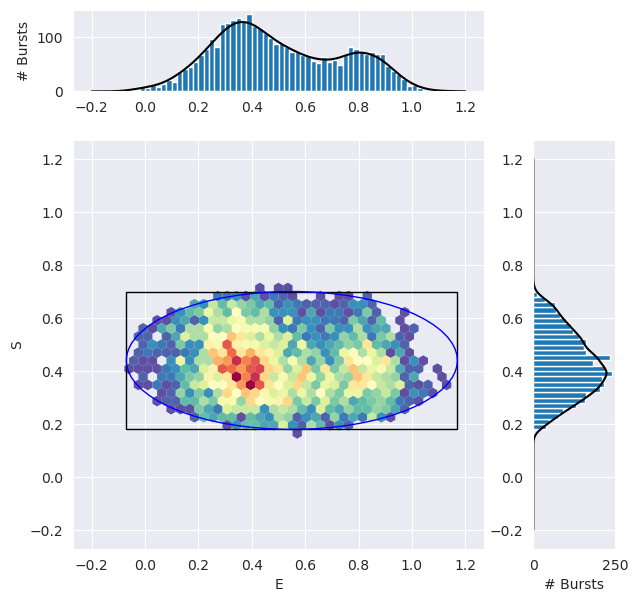

In [45]:
# g = alex_jointplot(d_fret_mix)
fig = plt.figure(figsize=(7,7))
cplotkw = smf.fretfactory.ALEXdefaults['hexbin']
cplotkw['cmap'] = 'Spectral_r'
axs, *_ = smf.plot.jointplot(data, bsdct['E'], bsdct['S'], fig=fig, gate=gellipse, hfunc=smf.plot.hist_kdeoverlay, cfunc=smf.plot.hexbin,
                             hplot_kwargs={'kdeplot_kwargs':{'c':'k'}, 'bins':smf.fretfactory.ALEXdefaults['ratio_bins']},
                             cplot_kwargs=cplotkw);
# bpl.plot_ES_selection(g.axes[0], **roi);
# note that there is not equivalent to plot_ES_selection, so plotting of regions done manually
rec = mpl.patches.Rectangle((-0.07, 0.18), 1.24, 0.52, transform=axs[0].transData, facecolor='none', edgecolor='k')
axs[0].add_patch(rec)
elp = mpl.patches.Ellipse((0.55, 0.44), 1.24, 0.52, transform=axs[0].transData, facecolor='none', edgecolor='b')
axs[0].add_patch(elp);

Now we can further separate high- and low FRET sub-populations. 

In [46]:
# roi_high_fret = dict(E1=0.65, E2=1.09, S1=-0.13, S2=0.96)
# d_high_fret = d_fret_mix.select_bursts(select_bursts.ES, **roi_high_fret)
gHighF = gellipse & smf.make_geq_gate(bsdct['E'], 0.65)
# roi_low_fret = dict(E1=-0.19, E2=0.64, S1=-0.05, S2=0.92)
# d_low_fret = d_fret_mix.select_bursts(select_bursts.ES, **roi_low_fret)
gLowF = gellipse & smf.make_lt_gate(bsdct['E'], 0.64)

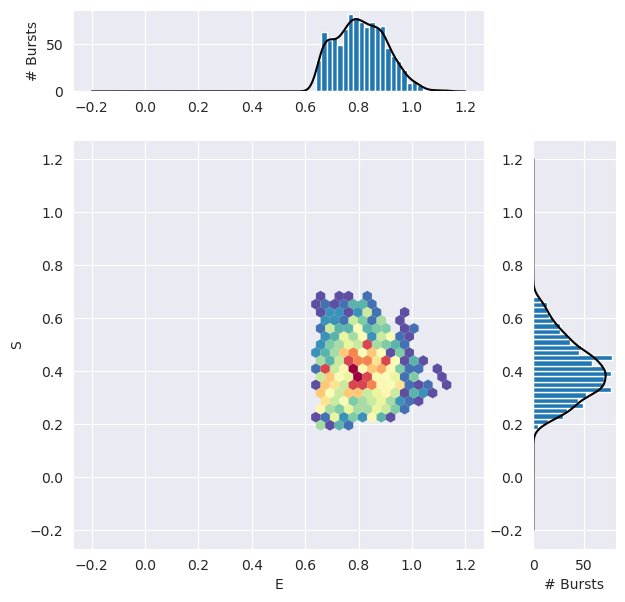

In [47]:
# alex_jointplot(d_high_fret);
fig = plt.figure(figsize=(7,7))
cplotkw = smf.fretfactory.ALEXdefaults['hexbin']
cplotkw['cmap'] = 'Spectral_r'
smf.plot.jointplot(data, bsdct['E'], bsdct['S'], fig=fig, gate=gHighF, hfunc=smf.plot.hist_kdeoverlay, cfunc=smf.plot.hexbin,
                   hplot_kwargs={'kdeplot_kwargs':{'c':'k'}, 'bins':smf.fretfactory.ALEXdefaults['ratio_bins']},
                   cplot_kwargs=cplotkw);

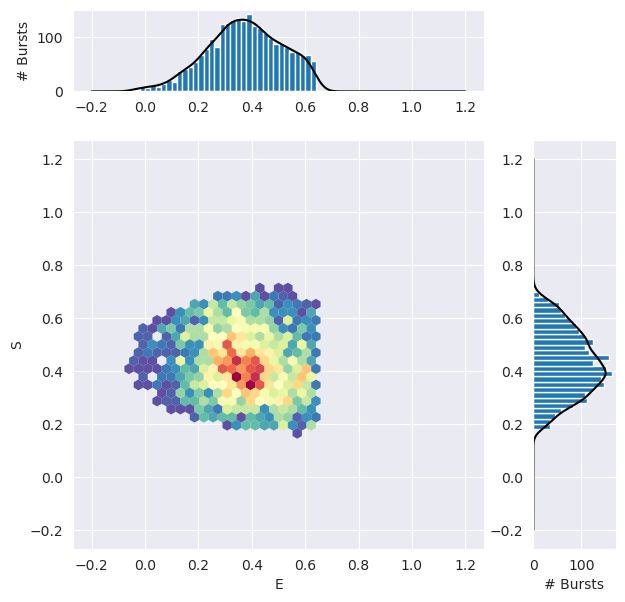

In [48]:
# alex_jointplot(d_low_fret);
fig = plt.figure(figsize=(7,7))
cplotkw = smf.fretfactory.ALEXdefaults['hexbin']
cplotkw['cmap'] = 'Spectral_r'
smf.plot.jointplot(data, bsdct['E'], bsdct['S'], fig=fig, gate=gLowF, hfunc=smf.plot.hist_kdeoverlay, cfunc=smf.plot.hexbin,
                   hplot_kwargs={'kdeplot_kwargs':{'c':'k'}, 'bins':smf.fretfactory.ALEXdefaults['ratio_bins']},
                   cplot_kwargs=cplotkw);

We can for example compute the ratio of high- and low-fret bursts:

In [49]:
# d_low_fret.num_bursts / d_high_fret.num_bursts
tlow = data.get_table(bsdct['bursts'].regate(gLowF)).size
thigh = data.get_table(bsdct['bursts'].regate(gHighF)).size
tlow, thigh, tlow / thigh

(np.int64(2419), np.int64(1004), np.float64(2.4093625498007967))

### Burst Width analysis

> **Original Text**
>
> To plot a burst-width histogram, we use `hist_width` instead of `hist_fret`:

We can access the burst duration (aka width) with "dur" columns, accesible from the `Dur` key in our bsdct.
So we can plot the histogram, and use the `rescale=-3` argument to change the unit from seconds to milliseconds:

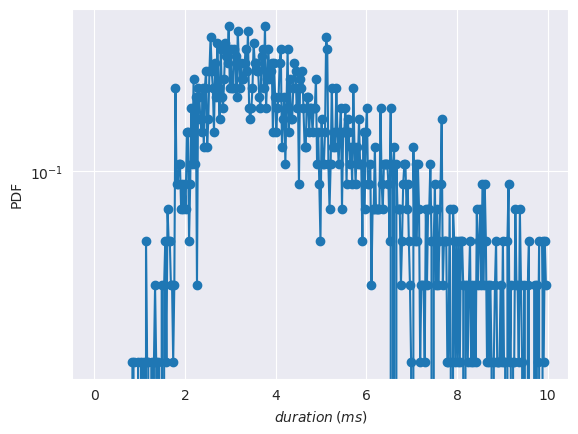

In [50]:
# dplot(d_low_fret, hist_width)
smf.plot.hist_line(data, bsdct['Dur'], gate=gLowF, rescale=-3, marker='o', bins=np.arange(0,10,0.025), include_unit=True, normalize='PDF')
plt.yscale('log');

> **Original Text**
>
> To use a larger bin size, plots two sub-populations (in different color) and add a legend:

We can just change the `bins` keyword argument to alter the size of the binds, 
and the `c` keyord arguemnt to chang the color, and the label argument to place appropriate labels on the plots.

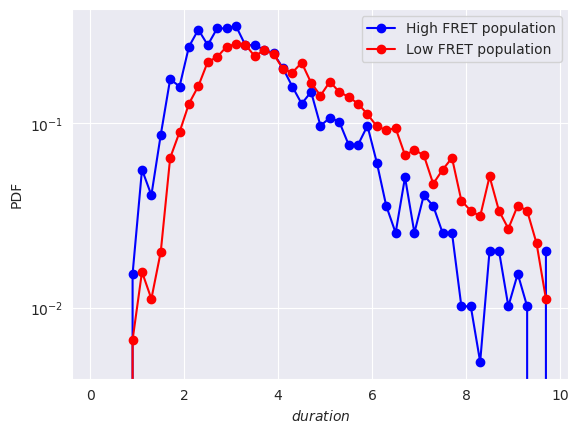

In [51]:
# ax = dplot(d_high_fret, hist_width, bins=(0, 10, 0.2))
# dplot(d_low_fret, hist_width, bins=(0, 10, 0.2), ax=ax)
# plt.legend(['High-FRET population', 'Low-FRET population']);
smf.plot.hist_line(data, bsdct['Dur'], gate=gHighF, bins=np.arange(0,10,0.2), rescale=-3, c='b', marker='o', label='High FRET population', normalize='PDF')
smf.plot.hist_line(data, bsdct['Dur'], gate=gLowF, bins=np.arange(0,10,0.2), rescale=-3, c='r', marker='o', label='Low FRET population', normalize='PDF')
plt.yscale('log')
plt.legend();

Finally, we compute the mean burst width for each subpopulation:

In [52]:
# millisec = d.clk_p * 1e3
# mean_b_width_low_fret  = d_low_fret.mburst[0].width.mean() * millisec
# mean_b_width_high_fret = d_high_fret.mburst[0].width.mean() * millisec
mean_b_width_high_fret = np.mean(data.get_column(bsdct['Dur'], gHighF))*1e3
mean_b_width_low_fret = np.mean(data.get_column(bsdct['Dur'], gLowF))*1e3
print('Mean burst width: %.1f ms (high-fret), %.1f (low-fret)' % 
      (mean_b_width_high_fret, mean_b_width_low_fret))

Mean burst width: 3.8 ms (high-fret), 5.1 (low-fret)


## FRET fit: in-depth example

Fitting is now performed more explicitly, therefore it is recomended to look at
the [MultiFit Tutorial](MultiFitTutorial.ipynb)

We can fit a FRET distribution to any model. For example, 

## Exporting Data

To export data computed by FRETBursts, you need to find first where 
the data is stored or, for data computed on fly, which function/method 
is used to computed it. 

Most data computed by FRETBursts is stored in the `Data` object
(see the [Data docs](http://fretbursts.readthedocs.org/en/latest/data_class.html) for the list of attributes).
For example:

- corrected burst counts are stored in `Data.nd`, `Data.na`, `Data.naa`
- timestamps are stored in `Data.ph_times_m`

All these attributes are list of arrays, one per excitation spot. 
This means that, even for single-spot data, we need to use indexing (`[0]`)
to obtain the array. For example:

In [53]:
# d.nd[0]
data.get_column(bsdct['E'], gate=gAll)

array([0.00104195, 1.02157817, 0.87976143, ..., 0.03944649, 0.40506656,
       0.01308185], shape=(5493,))

Any numpy array can be saved to disk with the method `.tofile()`. For example:

In [54]:
# d.nd[0].tofile('n_dd.csv', sep=',')
# data.get_column(bsdct['E'], gate=gAll).tofile('n_dd.csv', sep=',')

> **Old Text**
>
> The background data is stored in `Data.bg` (and `Data.bg_mean`) attribute (see [Background Estimation](#Background-estimation) in this notebook). This attribute is dict containing lists containing arrays (scalars) and ca be saved to disk similarly.

In this example, the `bgdct` dictionary contains a number of background related Columns and Params.
For instance `bgdct['BgDA']` specifies the donor excitation acceptor emission stream,
and we can do the same with these columns as with burst search columns.

### Exporting burst data

Part of burst data is stored in `Data` attributes (`mburst`, `nd`, `na`, `naa`)
and part is computed on fly (duration, raw counts, etc.).

To put all burst data in a single "table" (a `pandas.DataFrame`), one row
per burst, we can use `bext.burst_data`:

In [55]:
# bursts = bext.burst_data(ds)
# bursts
bursts = data.get_frame(*smf.fretfactory.get_columns(bsdct, gAll))
bursts

,$duration$,$E_{raw}$,$_{raw}n_{532ex}^{580em}$,$_{raw}n_{532ex}^{680em}$,$_{raw}n$,$_{5}\sigma_{n_{532ex}^{680em}/n_{532ex}}$,$^{ii}E_{app}$,$_{^{ii}I}n_{532ex}^{580em}$,$_{^{ii}I}n_{532ex}^{680em}$,$_{^{ii}I}n$,...,$_{raw}n_{532ex}$,$_{raw}n_{532ex}\:+\:_{raw}n_{635ex}^{680em}$,$^{ii}S_{app}$,$_{^{ii}I}n_{635ex}^{680em}$,$_{^{ii}I}n_{532ex}$,$_{^{ii}I}n_{532ex}\:+\:_{^{ii}I}n_{635ex}^{680em}$,S,$_{F}n_{635ex}^{680em}$,$_{F}n_{532ex}$,$_{F}n_{532ex}\:+\:_{F}n_{635ex}^{680em}$
0,0.002441,0.153846,33,6,43,0.098974,0.102645,31.578312,3.612109,37.647852,...,39,43,0.930241,2.638935,35.190421,37.829356,0.922951,2.638935,31.611249,34.250185
1,0.004378,0.941176,2,32,80,0.094281,1.020242,-0.549927,27.717101,70.400437,...,34,80,0.384119,43.558807,27.167175,70.725982,0.369116,43.558807,25.485314,69.044121
2,0.002501,0.846154,4,22,44,0.097980,0.884898,2.543388,19.553450,38.516376,...,26,44,0.570943,16.605501,22.096838,38.702339,0.560216,16.605501,21.152846,37.758346
3,0.003374,0.725000,11,29,107,0.171391,0.739886,9.034840,25.699285,99.601873,...,40,107,0.347853,65.118638,34.734124,99.852762,0.323472,65.118638,31.135546,96.254184
4,0.002676,0.292683,29,12,48,0.198431,0.254782,27.441223,9.381852,42.131759,...,41,48,0.869889,5.507692,36.823074,42.330766,0.859109,5.507692,33.584232,39.091924
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5488,0.003678,0.764706,4,13,41,0.249444,0.831818,1.884367,9.319987,32.841168,...,17,41,0.336985,22.044455,11.204354,33.248808,0.314533,22.044455,10.115295,32.159750
5489,0.001588,0.222222,21,6,39,0.126491,0.180057,20.086451,4.410938,35.476945,...,27,39,0.687107,11.155578,24.497389,35.652968,0.661924,11.155578,21.841656,32.997235
5490,0.002291,0.444444,5,4,39,0.000000,0.316818,3.682049,1.707505,33.917387,...,9,39,0.157722,28.781777,5.389554,34.171330,0.117530,28.781777,3.833257,32.615034
5491,0.003132,0.526316,9,10,50,0.163299,0.488194,7.198499,6.866399,43.052601,...,19,50,0.324078,29.334816,14.064898,43.399715,0.292019,29.334816,12.099671,41.434487


> **Original Text** : **NOTE**:
> For multi-spot data use the `ich` argument to get burst data
> for the different spots.
>
> **smfBursts implementation**
>
> Multispot data now becomes a `PhotonDataList`
> Access indvidual spots with `PhotonDataList.datas[i]`
> or a concatenated version can be created with the same
> `PhotonDataList.to_csv()` or `PhotonDataList.get_frame()`
> methods

This table (as any `pandas.DataFrame`) can be saved in a CSV text file with:

In [56]:
# bursts.to_csv('bursts.csv')
# bursts.to_csv('bursts.csv')

## Intensity timetrace and Rate timetrace

For an initial inspection of a data file, it is common to compute an intensity *timetrace* plot (or timetrace for short). 
We also can compute a similar plot called *ratetrace*, which does not bin counts 
but shows the instantaneous count rate. In both cases, it is convenient to scroll 
along the plot interactively.

In FRETBursts, the two *timetrace* and *ratetrace* plots support 
interactive scrolling. We just need to switch from the inline backend 
to QT, as we did before. 

<br>
<div class="alert alert-warning">
The graphical scrolling of timetraces requires a local FRETBursts installation.
Therefore the commands below are commented by default.
<br><br>
If you have a local installation and you want to try commands below,
please uncomment them by removing the inital <code>#</code>.
</div>


Here are the corresponding commands:

In [57]:
# %matplotlib ipympl # note that this replaces the older %matplotlib notebook

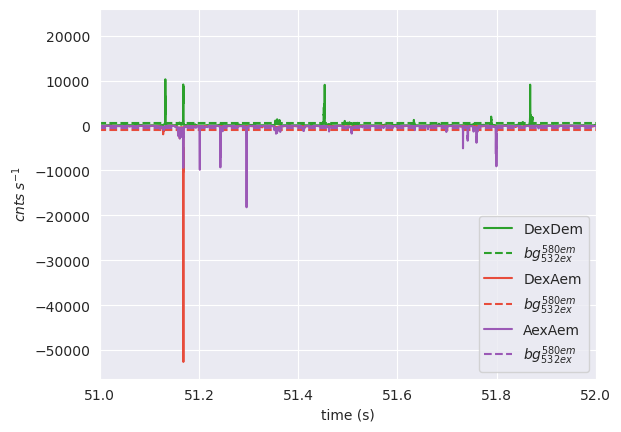

In [58]:
#dplot(ds, ratetrace, scroll=True, bursts=True)
smf.plot.ratetrace(data, streams=smf.fretfactory.ALEXdefaults['streams'][1:], 
                   stream_kwargs=smf.fretfactory.ALEXdefaults['stream_colors', ('label', 'stream_labels')][1:],
                   bg=bgdct['bg'], bg_kwargs={'ls':'--'}, tmin=50, tmax=53, bg_labels=True,
                   direction=[True, False, False], );
plt.xlim([51.0, 52.0]);

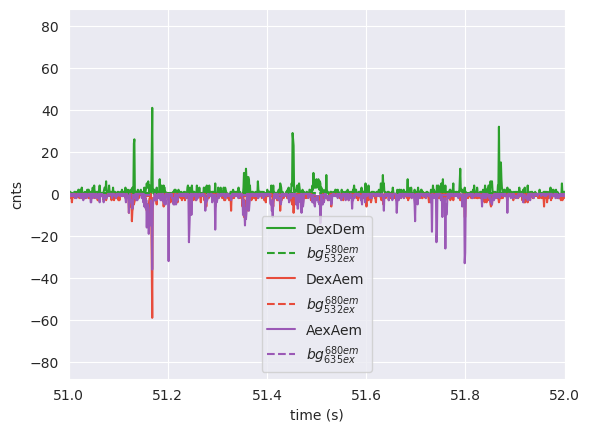

In [59]:
#dplot(ds, timetrace, tmax=600, scroll=True, bursts=True)
smf.plot.timetrace(data, streams=smf.fretfactory.ALEXdefaults['streams'][1:],
                   tmin=40.0, tmax=70.0, bg=bgdct['bg'], bg_labels=True,
                   stream_kwargs=smf.fretfactory.ALEXdefaults['stream_colors', ('label', 'stream_labels')][1:],
                   bg_kwargs={'ls':'--'},
                   direction=[True, False, False]);
plt.xlim([51.0, 52.0]);

In [60]:
#%matplotlib inline

**Reminder: print your citations (new to smfBursts)**

In [61]:
smf.print_citations()

1. Ingargiola, A., Lerner, E., Chung, S. Y., Weiss, S. & Michalet, X.
    FRETBursts: An open source toolkit for analysis of freely-diffusing Single-
    molecule FRET. PLoS ONE 11, 1–27 (2016).
2. Kapanidis, A. N. et al. Alternating-Laser Excitation of Single Molecules.
    Accounts of Chemical Research 38, 523–533 (2005).
3. Hellenkamp, B., Schmid, S., Doroshenko, O. et al. Precision and accuracy of
    single-molecule FRET measurements—a multi-laboratory benchmark study. Nat
    Methods 15, 669–676 (2018).
4. Nir, E. et al. Shot-noise limited single-molecule FRET histograms: Comparison
    between theory and experiments. Journal of Physical Chemistry B 110,
    22103–22124 (2006).
5. Eggeling, C., Fries, J. R., Brand, L., Günther, R. & Seidel, C. A. M.
    Monitoring conformational dynamics of a single molecule by selective
    fluorescence spectroscopy. Proc. Natl. Acad. Sci. U.S.A. 95, 1556–1561
    (1998).
6. Torella, J. P., Holden, S. J., Santoso, Y., Hohlbein, J. & Kapanidis, A

**and to show the params used with the `.description` property**

In [62]:
print(bsdct['ratios'].description)

Table: Ratios
Params:
  corr_mat: [[ 1.    0.    0.    0.  ]
             [-0.11  1.    0.   -0.04]
             [ 0.    0.    1.    0.  ]
             [ 0.    0.    0.    1.  ]]
Parents:
  nph:
    Table: NphBG
    Params:
      single: True
    Parents:
      base:
        Table: Bursts
        Params:
          func: smfbursts.bursttables.burstsearch_mwindowF_bg
          stream: 0ex_1em
          m: 10
          F: 6.0
          c: -1.0
          fuse: 0.0
        Parents:
          bg:
            Table: BG
            Params:
              compute_stream: single_all
              func: smfbursts.backgroundtables.exp_mlefit
              tail_min: [0.0005 0.0005 0.0005 0.0005 0.0005]
              auto_threshold: True
              F_bg: 1.7
            Parents:
              base:
                Table: Periods
                Params:
                  period: 30.0
                  start_at: time_min
                  stop_at: over
                  detdef: DetDef2ex2em
      bg

<s>

Note that, to save memory, the previous plots stops will show the first 200 s
of measurement.
For both `timetrace` and `ratetrace`, you can extent (or reduce) the plotted 
region passing the `tmin` and `tmax` arguments (values in seconds).

> **Related documentation:**
>
> - [bpl.timetrace](http://fretbursts.readthedocs.org/en/latest/plots.html#fretbursts.burst_plot.timetrace)
> - [bpl.ratetrace](http://fretbursts.readthedocs.org/en/latest/plots.html#fretbursts.burst_plot.ratetrace)
</s>

<br>
<div class="alert alert-success">
This ends of the tutorial.
</div>

----

*Please send feedback and/or question by opening a new [GitHub Issue](https://github.com/OpenSMFS/smfBursts/issues).*